<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Feature%2FSecao2/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Seção 1: Introdução
----------------------------------------
● 1.1. Contextualização: Recapitule brevemente o problema de negócio ou pesquisa que você se propôs a resolver no Projeto 1.

● 1.2. Objetivo: Qual pergunta específica você está tentando responder com esta
análise?

● 1.3. Descrição dos Dados: Apresente o dataset, sua fonte e um dicionário de dados
(descrição das colunas/variáveis mais importantes).

*   List item
*   List item



-----------------------------------------------
#Seção 2: Análise Exploratória de Dados (EDA)
-----------------------------------------------
● 2.1. Carregamento e Limpeza dos Dados: Importe os dados e mostre os primeiros
passos de verificação (ex: .info(), .describe(), .isnull().sum()). Descreva como tratou
dados faltantes, duplicados ou inconsistentes.

● 2.2. Análise Univariada: Explore as variáveis individualmente. Use gráficos
(histogramas, boxplots, etc) e métricas para entender a distribuição e as características
de cada variável relevante. Comente suas observações.

● 2.3. Análise Bivariada e Multivariada: Investigue a relação entre as variáveis. Use
gráficos (scatter plots, heatmaps de correlação) e tabelas para identificar padrões,
tendências e correlações.

● 2.4. Insights da Eda: Faça um resumo do que você aprendeu nesta fase. A análise
confirmou sua hipótese inicial? Surgiram novas perguntas? Quais variáveis parecem
ser mais promissoras para a modelagem?

In [23]:
dataset <- read.csv ("Customers.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

[1] "Dataset Instalado com Sucesso"


In [25]:
library(ggplot2)
library(tidyr)
library(dplyr)

In [34]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == "" ), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c), 2),"\t"))
    cat(paste("Mediana", round(median(c), 2),"\n"))

  } else {
      c_filtrado <- c[c != "" & !is.na(c)]
      cat(paste("Máximo caracteres:", max(nchar(c_filtrado)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c_filtrado)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}
info_colun_num(dataset$Family.Size)

Tipo: integer | NAs: 0 | Únicos: 9 
5 primeiros elementos: 4  -  3  -  1  -  2  -  6 
Mínimo: 1 	1ºQuart: 2 	Média: 3.77 	3ºQuart: 5 	Máximo: 9 
Desvio Padrão: 1.97 	Mediana 4 


In [45]:
#Coluna Id
cat("Custumer Id\n")
info_colun_num(dataset$CustomerID)
cat("-------------------------------------------------\n")
#Coluna Genero
cat("Gender\n")
info_colun_num(dataset$Gender)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Age\n")
info_colun_num(dataset$Age)
cat("-------------------------------------------------\n")
#Coluna Salario Anual
cat("Annual.Income....\n")
info_colun_num(dataset$Annual.Income....)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Spending.Score..1.100.\n")
info_colun_num(dataset$Spending.Score..1.100.)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Profession\n")
info_colun_num(dataset$Profession)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Experience\n")
info_colun_num(dataset$Work.Experience)
cat("-------------------------------------------------\n")
#Coluna Familiares
cat("Family Size\n")
info_colun_num(dataset$Family.Size)
cat("-------------------------------------------------\n")

Custumer Id
Tipo: integer | NAs: 0 | Únicos: 2000 
5 primeiros elementos: 1  -  2  -  3  -  4  -  5 
Mínimo: 1 	1ºQuart: 500.75 	Média: 1000.5 	3ºQuart: 1500.25 	Máximo: 2000 
Desvio Padrão: 577.49 	Mediana 1000.5 
-------------------------------------------------
Gender
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Male  -  Male  -  Female  -  Female  -  Female 
Máximo caracteres: 6 	Mínimo caracteres: 4 
Frequncia Absoluta
Female   Male 
  1186    814 
Frequencia Relativa
Female   Male 
  59.3   40.7 
-------------------------------------------------
Age
Tipo: integer | NAs: 0 | Únicos: 100 
5 primeiros elementos: 19  -  21  -  20  -  23  -  31 
Mínimo: 0 	1ºQuart: 25 	Média: 48.96 	3ºQuart: 73 	Máximo: 99 
Desvio Padrão: 28.43 	Mediana 48 
-------------------------------------------------
Annual.Income....
Tipo: integer | NAs: 0 | Únicos: 1786 
5 primeiros elementos: 15000  -  35000  -  86000  -  59000  -  38000 
Mínimo: 0 	1ºQuart: 74572 	Média: 110731.82 	3ºQuart: 1

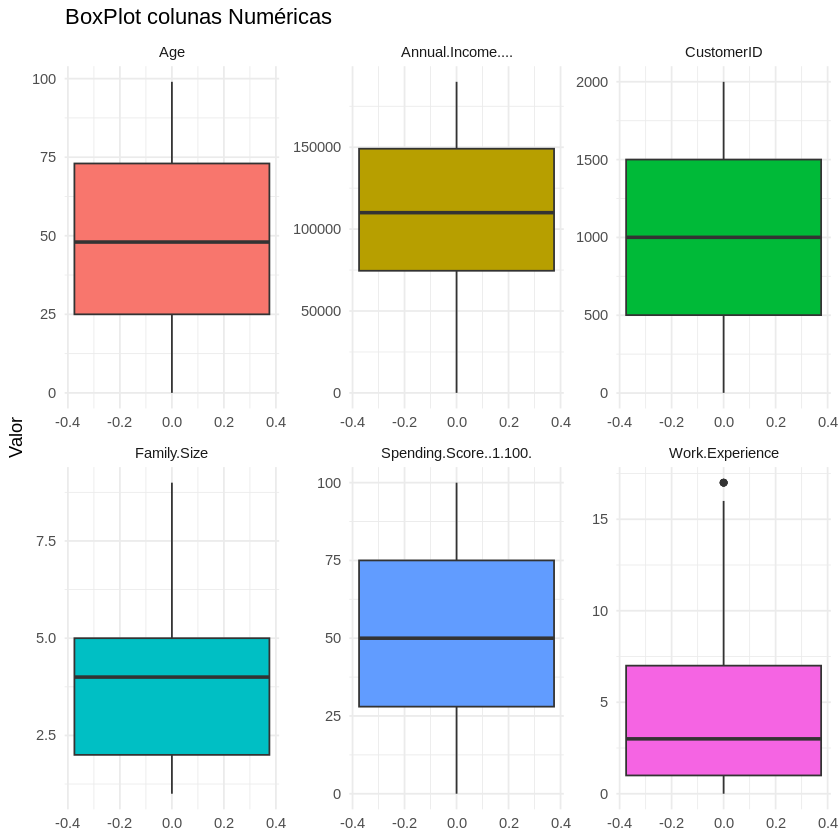

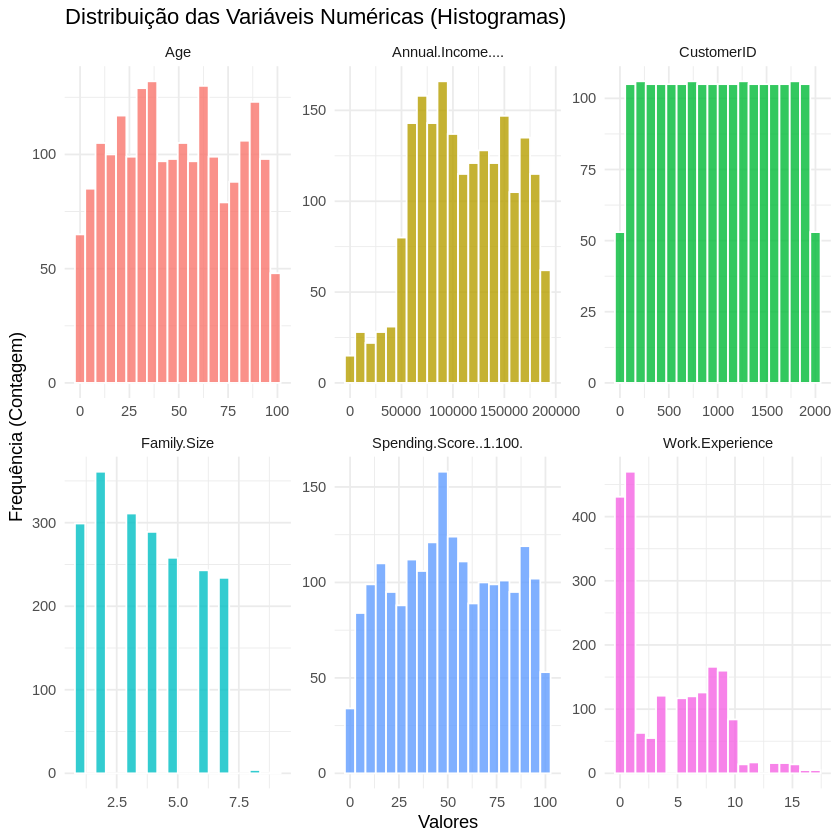

In [46]:
dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(y = Valor, fill = Variavel)) +
  geom_boxplot() +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "BoxPlot colunas Numéricas")

dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(x = Valor, fill = Variavel)) +
  geom_histogram(bins = 20, color = "white", alpha = 0.8) +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    title = "Distribuição das Variáveis Numéricas (Histogramas)",
    x = "Valores",
    y = "Frequência (Contagem)"
  )

In [21]:
dataset$Profession[dataset$Profession == ""] <- "Sem Profissão"

   CustomerID           Gender          Age        Annual.Income....
 Min.   :   1.0   Length   :2000   Min.   : 0.00   Min.   :     0   
 1st Qu.: 500.8   N.unique :   2   1st Qu.:25.00   1st Qu.: 74572   
 Median :1000.5   N.blank  :   0   Median :48.00   Median :110045   
 Mean   :1000.5   Min.nchar:   4   Mean   :48.96   Mean   :110732   
 3rd Qu.:1500.2   Max.nchar:   6   3rd Qu.:73.00   3rd Qu.:149093   
 Max.   :2000.0                    Max.   :99.00   Max.   :189974   
 Spending.Score..1.100.     Profession   Work.Experience   Family.Size   
 Min.   :  0.00         Length   :2000   Min.   : 0.000   Min.   :1.000  
 1st Qu.: 28.00         N.unique :  10   1st Qu.: 1.000   1st Qu.:2.000  
 Median : 50.00         N.blank  :   0   Median : 3.000   Median :4.000  
 Mean   : 50.96         Min.nchar:   6   Mean   : 4.103   Mean   :3.768  
 3rd Qu.: 75.00         Max.nchar:  13   3rd Qu.: 7.000   3rd Qu.:5.000  
 Max.   :100.00                          Max.   :17.000   Max.   :9.000  

In [13]:
head(dataset)

,CustomerID,Gender,Age,Annual.Income....,Spending.Score..1.100.,Profession,Work.Experience,Family.Size
,<int>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>
1,1,Male,19,15000,39,Healthcare,1,4
2,2,Male,21,35000,81,Engineer,3,3
3,3,Female,20,86000,6,Engineer,1,1
4,4,Female,23,59000,77,Lawyer,0,2
5,5,Female,31,38000,40,Entertainment,2,6
6,6,Female,22,58000,76,Artist,0,2


-----------------------------------------------
#Seção 3: Validação Estatística (Teste de Hipóteses)
-----------------------------------------------
● 3.1. Definição das Hipóteses: Declare formalmente a Hipótese Nula e a Hipótese
Alternativa. As hipóteses devem estar relacionadas aos padrões identificados na EDA.

● 3.2. Escolha a Execução do Teste: Utilize o teste adequado para o seu tema (Teste t,
ANOVA, Qui-quadrado, Teste de Correlação de Pearson, etc.).

● 3.3. Interpretação do p-valor: Com base em um nível de significância (ex: 5%),
determine se há evidências para rejeitar a hipótese nula e valide se o padrão encontrado
na EDA é estatisticamente significante.

-----------------------------------------------
#Seção 4: Pré-processamento e Aplicação da Técnica
-----------------------------------------------
● 4.1. Preparação dos Dados para o Modelo: Descreva e execute os passos necessários
para preparar os dados para a sua técnica específica (ex: normalização/padronização
para K-Means, criação de variáveis dummy para regressão, etc.).

● 4.2. Modelagem: Aplicação do algoritmo do seu tema. Explique a escolha de
parâmetros, se houver.

-----------------------------------------------
#Seção 5: Resultados e Interpretação
-----------------------------------------------
● 5.1. Apresentação dos Resultados: Mostre a saída do seu modelo de forma clara.
Pode ser uma tabela com coeficientes, uma visualização dos clusters, uma imagem da
árvore de decisão, etc.

● 5.2. Análise Crítica dos Resultados: Esta é a parte mais importante. Traduza a
saída técnica em uma explicação clara e objetiva.
  
○ Exemplo para K-Means: "O modelo identificou 3 clusters. O Cluster 1, que
chamamos de 'Clientes Econômicos', é caracterizado por... O Cluster 2,
'Clientes Premium', por sua vez..."
  
○ Exemplo para Regressão Linear: "O coeficiente para a variável 'área_m2' foi
de 850. Isso sugere que, mantendo as outras variáveis constantes, cada metro
quadrado adicional está associado a um aumento de R$850 no preço do
aluguel."

-----------------------------------------------
#Seção 6: Conclusão
-----------------------------------------------
● 6.1. Resumo dos Insights: Sintetize as principais descobertas do seu projeto.
Responda diretamente à pergunta que você se propôs a investigar na introdução.

● 6.2. Recomendações Práticas: Com base nos seus achados, o que você recomendaria
para uma empresa ou área de estudo? Proponha 1 ou 2 ações concretas.

● 6.3. Limitações e Próximos Passos: Nenhum projeto é perfeito. Discuta as limitações
da sua análise (ex: poucos dados, variáveis faltantes, simplicidade do modelo).